In [65]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import dask.dataframe as dd
from dask import delayed, compute
import dask.array as da
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [66]:
df = dd.read_csv('/home/pipc06/Documents/OSIRIS/Toy Data/osiris_toydata_7.csv', sep=' ', header=None)
df = df.rename(columns={0: "time", 1: "energy", 2: "x", 3: "y", 4: "z", 9: "truth"})

In [67]:
# Convert all columns to float
df = df.astype(float)

In [68]:
df['energy'] = df['energy'] / 280

In [69]:
# Calculate additional features: time differences and distances
df['time_diff'] = df['time'].diff().fillna(0)
df['distance'] = np.sqrt(df['x'].diff().fillna(0)**2 + df['y'].diff().fillna(0)**2 + df['z'].diff().fillna(0)**2)
df['r'] = np.sqrt(df['x']**2 + df['y']**2)

In [70]:
df = df.compute()

Total events with truth 1 =  2165960  and total truth2 events =  2121073
Overlapping range: 0.00 to 4.44
The number of overlapping events is NOT equal.

Number of overlapping events for Truth 1: 2157014
Number of overlapping events for Truth 4: 2121072

Overlapping events for Truth 1:
2157014

Overlapping events for Truth 4:
2121072


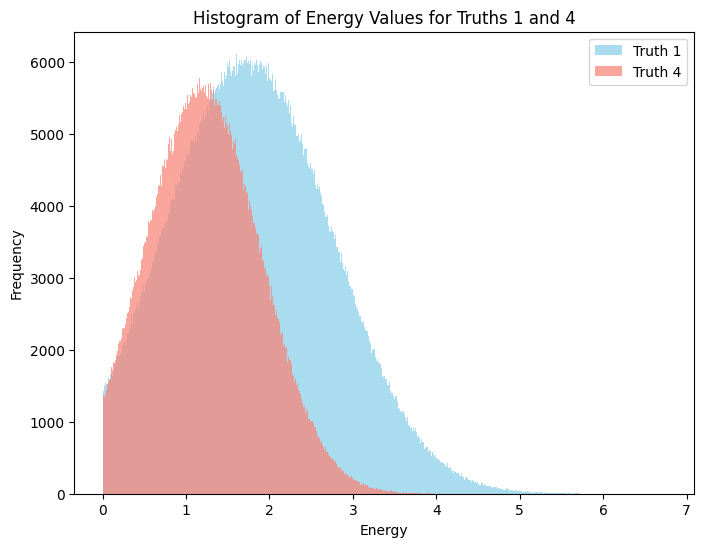

In [63]:
# Filter the data for truth values 1 and 4
energy_truth_1 = df[df['truth'] == 1]['energy']
energy_truth_4 = df[df['truth'] == 4]['energy']

print("Total events with truth 1 = ", len(energy_truth_1), " and total truth2 events = ", len(energy_truth_4) )

# Create histograms for truths 1 and 4
hist_1, bin_edges_1 = np.histogram(energy_truth_1, bins=1000)
hist_4, bin_edges_4 = np.histogram(energy_truth_4, bins=1000)

# Find the overlapping range
overlap_min = max(bin_edges_1[0], bin_edges_4[0])
overlap_max = min(bin_edges_1[-1], bin_edges_4[-1])

# Print overlapping range
if overlap_min < overlap_max:
    print(f"Overlapping range: {overlap_min:.2f} to {overlap_max:.2f}")

    # Filter the DataFrame for events within the overlapping range
    overlapping_events_truth_1 = df[(df['truth'] == 1) & 
                                     (df['energy'] >= overlap_min) & 
                                     (df['energy'] <= overlap_max)]
    
    overlapping_events_truth_4 = df[(df['truth'] == 4) & 
                                     (df['energy'] >= overlap_min) & 
                                     (df['energy'] <= overlap_max)]
    
    # Count the number of overlapping events
    count_overlap_1 = len(overlapping_events_truth_1)
    count_overlap_4 = len(overlapping_events_truth_4)

    # Check if the counts are equal
    if count_overlap_1 == count_overlap_4:
        print("The number of overlapping events is equal.")
    else:
        print("The number of overlapping events is NOT equal.")
        
    print(f"\nNumber of overlapping events for Truth 1: {count_overlap_1}")
    print(f"Number of overlapping events for Truth 4: {count_overlap_4}")
    
    # Print the overlapping events
    print("\nOverlapping events for Truth 1:")
    print(len(overlapping_events_truth_1))

    print("\nOverlapping events for Truth 4:")
    print(len(overlapping_events_truth_4))
else:
    print("No overlapping range found.")

# Plot histograms for each truth value with different colors
plt.figure(figsize=(8, 6))
plt.hist(energy_truth_1, bins=1000, color='skyblue', alpha=0.7, label='Truth 1')
plt.hist(energy_truth_4, bins=1000, color='salmon', alpha=0.7, label='Truth 4')

# Add labels and legend
plt.title("Histogram of Energy Values for Truths 1 and 4")
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.legend()

Total events with truth 1 =  2165960  and total truth2 events =  2121073
Overlapping range: 0.68 to 0.95
The number of overlapping events is NOT equal.

Number of overlapping events for Truth 2: 2151592
Number of overlapping events for Truth 5: 2049994

Overlapping events for Truth 2:
2151592

Overlapping events for Truth 5:
2049994


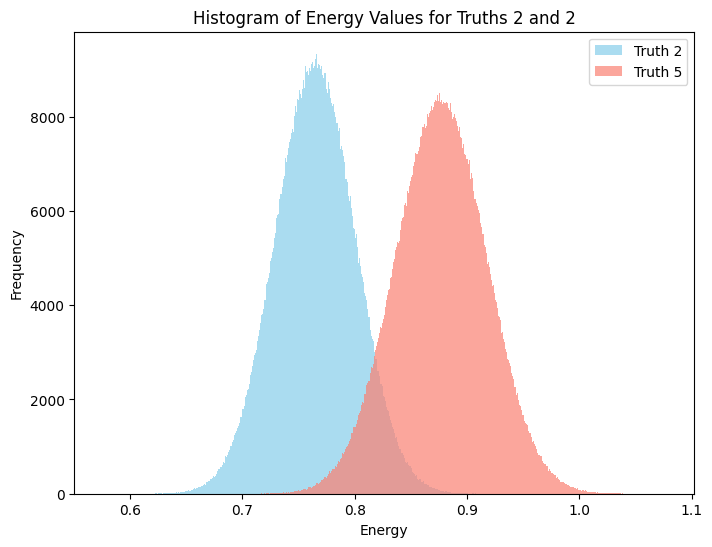

In [64]:
# Filter the data for truth values 1 and 4
energy_truth_2 = df[df['truth'] == 2]['energy']
energy_truth_5 = df[df['truth'] == 5]['energy']

print("Total events with truth 1 = ", len(energy_truth_1), " and total truth2 events = ", len(energy_truth_4) )

# Create histograms for truths 1 and 4
hist_2, bin_edges_2 = np.histogram(energy_truth_2, bins=1000)
hist_5, bin_edges_5 = np.histogram(energy_truth_5, bins=1000)

# Find the overlapping range
overlap_min = max(bin_edges_2[0], bin_edges_5[0])
overlap_max = min(bin_edges_2[-1], bin_edges_5[-1])

# Print overlapping range
if overlap_min < overlap_max:
    print(f"Overlapping range: {overlap_min:.2f} to {overlap_max:.2f}")

    # Filter the DataFrame for events within the overlapping range
    overlapping_events_truth_2 = df[(df['truth'] == 2) & 
                                     (df['energy'] >= overlap_min) & 
                                     (df['energy'] <= overlap_max)]
    
    overlapping_events_truth_5 = df[(df['truth'] == 5) & 
                                     (df['energy'] >= overlap_min) & 
                                     (df['energy'] <= overlap_max)]
    
    # Count the number of overlapping events
    count_overlap_2 = len(overlapping_events_truth_2)
    count_overlap_5 = len(overlapping_events_truth_5)

    # Check if the counts are equal
    if count_overlap_2 == count_overlap_5:
        print("The number of overlapping events is equal.")
    else:
        print("The number of overlapping events is NOT equal.")
        
    print(f"\nNumber of overlapping events for Truth 2: {count_overlap_2}")
    print(f"Number of overlapping events for Truth 5: {count_overlap_5}")
    
    # Print the overlapping events
    print("\nOverlapping events for Truth 2:")
    print(len(overlapping_events_truth_2))

    print("\nOverlapping events for Truth 5:")
    print(len(overlapping_events_truth_5))
else:
    print("No overlapping range found.")

# Plot histograms for each truth value with different colors
plt.figure(figsize=(8, 6))
plt.hist(energy_truth_2, bins=1000, color='skyblue', alpha=0.7, label='Truth 2')
plt.hist(energy_truth_5, bins=1000, color='salmon', alpha=0.7, label='Truth 5')

# Add labels and legend
plt.title("Histogram of Energy Values for Truths 2 and 2")
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.legend()

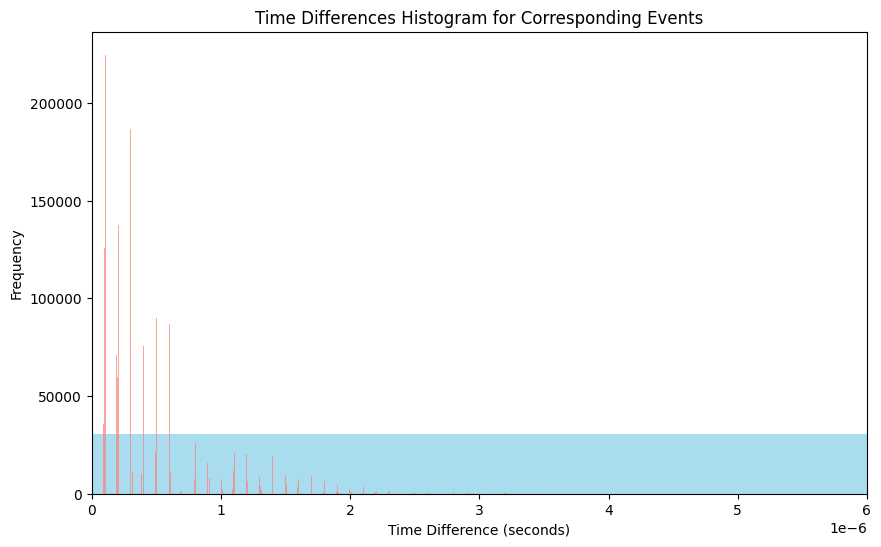

In [53]:
# Get time for truths 4 and 5
time_1 = df[df['truth'] == 1]['time'].reset_index(drop=True)
time_2 = df[df['truth'] == 2]['time'].reset_index(drop=True)

# Ensure both DataFrames have the same length
min_length = min(len(time_1), len(time_2))
time_1 = time_1.iloc[:min_length]
time_2 = time_2.iloc[:min_length]

# Calculate time differences between corresponding pairs of events
time_diffs_12 = time_2 - time_1

# Get time for truths 4 and 5
time_4 = df[df['truth'] == 4]['time'].reset_index(drop=True)
time_5 = df[df['truth'] == 5]['time'].reset_index(drop=True)

# Ensure both DataFrames have the same length
min_length = min(len(time_4), len(time_5))
time_4 = time_4.iloc[:min_length]
time_5 = time_5.iloc[:min_length]

# Calculate time differences between corresponding pairs of events
time_diffs_45 = time_5 - time_4

# Now you can plot these time differences as a histogram
plt.figure(figsize=(10, 6))
plt.hist(time_diffs_12, bins=1000, color='skyblue', alpha=0.7, label='Truths 1 and 2')
plt.hist(time_diffs_45, bins=1000, color='salmon', alpha=0.7, label='Truths 4 and 5')

# Add labels and title
plt.title("Time Differences Histogram for Corresponding Events")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.xlim(0,6e-6)
plt.show()

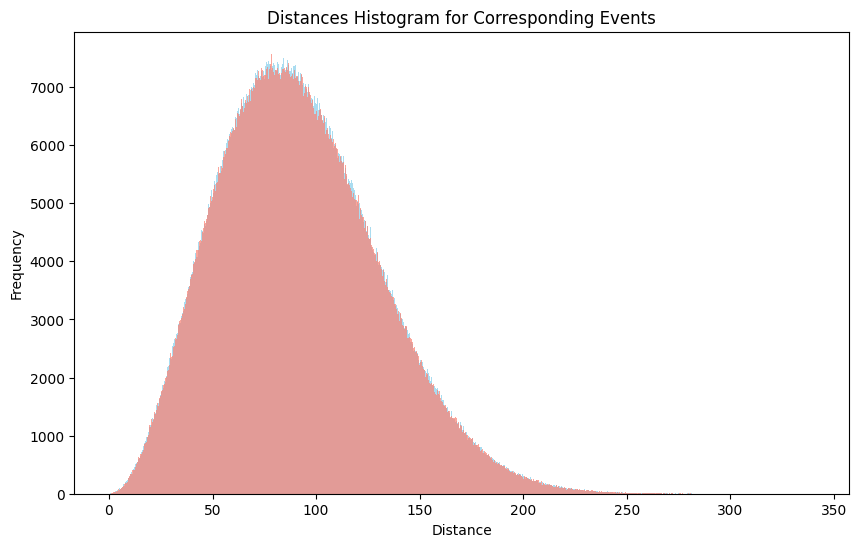

In [49]:
# Get coordinates for truths 4 and 5
coords_1 = df[df['truth'] == 1][['x', 'y', 'z']].reset_index(drop=True)
coords_2 = df[df['truth'] == 2][['x', 'y', 'z']].reset_index(drop=True)

# Ensure both DataFrames have the same length
min_length = min(len(coords_1), len(coords_2))
coords_1 = coords_1.iloc[:min_length]
coords_2 = coords_2.iloc[:min_length]

# Get coordinates for truths 4 and 5
coords_4 = df[df['truth'] == 4][['x', 'y', 'z']].reset_index(drop=True)
coords_5 = df[df['truth'] == 5][['x', 'y', 'z']].reset_index(drop=True)

# Ensure both DataFrames have the same length
min_length = min(len(coords_4), len(coords_5))
coords_4 = coords_4.iloc[:min_length]
coords_5 = coords_5.iloc[:min_length]

# Calculate distances between corresponding pairs of events
distances_12 = np.linalg.norm(coords_1.values - coords_2.values, axis=1)

# Calculate distances between corresponding pairs of events
distances_45 = np.linalg.norm(coords_4.values - coords_5.values, axis=1)


# Now you can plot these distances as a histogram
plt.figure(figsize=(10, 6))
plt.hist(distances_12, bins=1000, color='skyblue', alpha=0.7, label='Truths 1 and 2')
plt.hist(distances_45, bins=1000, color='salmon', alpha=0.7, label='Truths 4 and 5')

# Add labels and title
plt.title("Distances Histogram for Corresponding Events")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

In [7]:
df.describe()

,time,energy,x,y,z,5,6,7,8,truth,time_diff,distance,r
count,1.288607e+07,1.288607e+07,1.288607e+07,1.288607e+07,1.288607e+07,12886066.0,12886066.0,12886066.0,12886066.0,1.288607e+07,1.288607e+07,1.288607e+07,1.288607e+07
mean,4.847676e+07,1.899636e+00,-4.174741e-01,6.513237e-01,-1.745050e-01,0.0,0.0,0.0,0.0,2.487612e+00,7.509506e+00,1.316931e+03,1.045614e+03
std,2.793277e+07,1.993401e+00,7.825789e+02,7.826506e+02,9.031241e+02,0.0,0.0,0.0,0.0,1.704907e+00,1.057041e+01,1.045143e+03,3.628552e+02
min,9.978959e+04,1.785714e-09,-1.766146e+03,-1.834166e+03,-1.811258e+03,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.279984e-02
25%,2.427852e+07,7.900346e-01,-6.370280e+02,-6.360274e+02,-7.888812e+02,0.0,0.0,0.0,0.0,1.000000e+00,1.681000e-04,1.171737e+02,7.919150e+02
50%,4.847996e+07,1.017424e+00,-2.962708e-01,9.793633e-01,2.949296e-01,0.0,0.0,0.0,0.0,2.000000e+00,3.292927e+00,1.401611e+03,1.118426e+03
75%,7.267089e+07,2.191066e+00,6.360025e+02,6.373719e+02,7.877991e+02,0.0,0.0,0.0,0.0,4.000000e+00,1.104828e+01,2.190055e+03,1.351603e+03
max,9.686778e+07,1.019642e+01,1.823368e+03,1.770674e+03,1.928509e+03,0.0,0.0,0.0,0.0,5.000000e+00,1.935161e+02,4.340792e+03,1.866639e+03


In [71]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

In [72]:
# Initialize MinMaxScaler for energy and r
min_max_scaler = MinMaxScaler()

# Apply Min-Max Scaling to energy and r
df[['energy', 'r']] = min_max_scaler.fit_transform(df[['energy', 'r']])

In [73]:
# Initialize RobustScaler for z and time_diff
robust_scaler = RobustScaler()

# Apply Robust Scaling to z and time_diff
df[['z', 'time_diff']] = robust_scaler.fit_transform(df[['z', 'time_diff']])

In [74]:
# Ensure distance values are positive by adding a small constant if necessary
df['distance'] = np.log1p(df['distance'])  # log1p is used to apply log(1 + x) to avoid issues with 0 values

In [12]:
df.describe()

,time,energy,x,y,z,5,6,7,8,truth,time_diff,distance,r
count,1.288607e+07,1.288607e+07,1.288607e+07,1.288607e+07,1.288607e+07,12886066.0,12886066.0,12886066.0,12886066.0,1.288607e+07,1.288607e+07,1.288607e+07,1.288607e+07
mean,4.847676e+07,1.863041e-01,-4.174741e-01,6.513237e-01,-2.977361e-04,0.0,0.0,0.0,0.0,2.487612e+00,3.816560e-01,6.464550e+00,5.601462e-01
std,2.793277e+07,1.955000e-01,7.825789e+02,7.826506e+02,5.728010e-01,0.0,0.0,0.0,0.0,1.704907e+00,9.567612e-01,1.506362e+00,1.943951e-01
min,9.978959e+04,0.000000e+00,-1.766146e+03,-1.834166e+03,-1.148966e+00,0.0,0.0,0.0,0.0,0.000000e+00,-2.980533e-01,0.000000e+00,0.000000e+00
25%,2.427852e+07,7.748154e-02,-6.370280e+02,-6.360274e+02,-5.005302e-01,0.0,0.0,0.0,0.0,1.000000e+00,-2.980381e-01,4.772156e+00,4.242302e-01
50%,4.847996e+07,9.978248e-02,-2.962708e-01,9.793633e-01,-1.760240e-20,0.0,0.0,0.0,0.0,2.000000e+00,0.000000e+00,7.246091e+00,5.991546e-01
75%,7.267089e+07,2.148857e-01,6.360025e+02,6.373719e+02,4.994698e-01,0.0,0.0,0.0,0.0,4.000000e+00,7.019619e-01,7.692138e+00,7.240759e-01
max,9.686778e+07,1.000000e+00,1.823368e+03,1.770674e+03,1.222958e+00,0.0,0.0,0.0,0.0,5.000000e+00,1.721771e+01,8.376042e+00,1.000000e+00


In [75]:
# Replace 4 with 1 and 5 with 2 in the 'truth' column
df['truth'] = df['truth'].replace({3: 0, 4: 1, 5: 2})

In [76]:
X = df[['energy', 'r', 'z', 'time_diff', 'distance']]
y = df['truth']

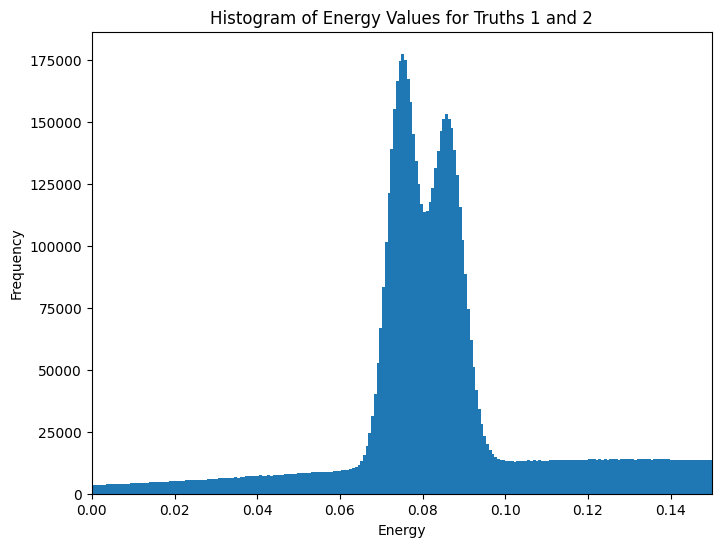

In [27]:
import matplotlib.pyplot as plt
# Filter the data to include only rows where 'truth' is 1 or 2
filtered_df = df[df['truth'].isin([1, 2])]

# Plot a histogram of the energy values
plt.figure(figsize=(8, 6))
plt.hist(filtered_df['energy'], bins=1000)
plt.title("Histogram of Energy Values for Truths 1 and 2")
plt.xlabel("Energy")
plt.ylabel("Frequency")
# Set x and y axis boundaries
plt.xlim(0, 0.15)  # Set x-axis range
plt.show()

In [77]:
# One-hot encode the target variable
y_cat = to_categorical(y)  # Convert to pandas Series before one-hot encoding
#y1_cat = da.from_array(y1_cat, chunks=(10000, y1_cat.shape[1]))  # Convert to Dask array
#y1_cat = dd.from_dask_array(da.from_array(y1_cat, chunks=(100000, y1_cat.shape[1])))  # Convert to Dask DataFrame


In [78]:
total_events = len(X)

In [79]:
# Further split using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)


Simple ANN

In [80]:
def simple_model_ann (input_shape, output_shape):
    model= keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Flatten(),
            layers.Dense (256, activation = "relu"),
            layers.Dense (256, activation = "relu"),
            layers.Dense (output_shape, activation = "softmax"),
        
        ]
    )
    model.compile (loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    
    return model

In [81]:
model = simple_model_ann(X_train.shape[1], y_train.shape[1])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 5)                 0         
                                                                 
 dense_3 (Dense)             (None, 256)               1536      
                                                                 
 dense_4 (Dense)             (None, 256)               65792     
                                                                 
 dense_5 (Dense)             (None, 3)                 771       
                                                                 
Total params: 68099 (266.01 KB)
Trainable params: 68099 (266.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [82]:
callbacks=[
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
     keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

In [83]:
# Train models
history = model.fit(X_train, y_train, epochs=200, batch_size=10000, verbose=2,
                      validation_data=(X_val, y_val),
                      callbacks=callbacks)

Epoch 1/200
825/825 - 119s - loss: 0.3835 - accuracy: 0.7992 - val_loss: 0.3379 - val_accuracy: 0.8240 - lr: 0.0010 - 119s/epoch - 144ms/step
Epoch 2/200
825/825 - 115s - loss: 0.3355 - accuracy: 0.8262 - val_loss: 0.3321 - val_accuracy: 0.8296 - lr: 0.0010 - 115s/epoch - 140ms/step
Epoch 3/200
825/825 - 116s - loss: 0.3327 - accuracy: 0.8280 - val_loss: 0.3312 - val_accuracy: 0.8289 - lr: 0.0010 - 116s/epoch - 140ms/step
Epoch 4/200
825/825 - 116s - loss: 0.3316 - accuracy: 0.8289 - val_loss: 0.3305 - val_accuracy: 0.8293 - lr: 0.0010 - 116s/epoch - 140ms/step
Epoch 5/200
825/825 - 116s - loss: 0.3314 - accuracy: 0.8289 - val_loss: 0.3301 - val_accuracy: 0.8296 - lr: 0.0010 - 116s/epoch - 141ms/step
Epoch 6/200
825/825 - 116s - loss: 0.3308 - accuracy: 0.8293 - val_loss: 0.3297 - val_accuracy: 0.8307 - lr: 0.0010 - 116s/epoch - 140ms/step
Epoch 7/200
825/825 - 116s - loss: 0.3306 - accuracy: 0.8295 - val_loss: 0.3301 - val_accuracy: 0.8289 - lr: 0.0010 - 116s/epoch - 140ms/step
Epoch 

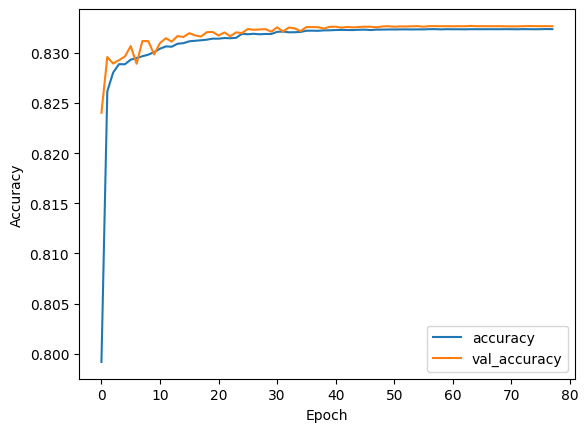

In [84]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

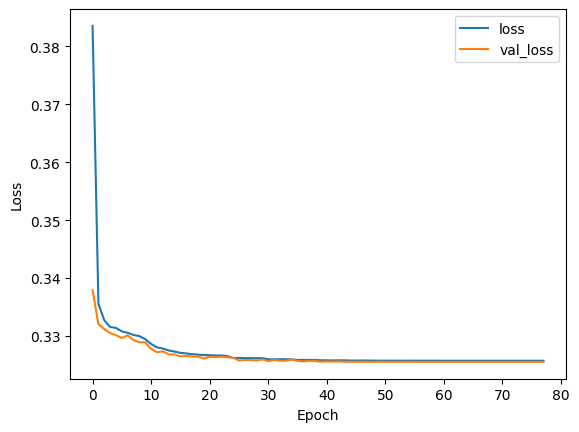

In [85]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [86]:
# Predict the labels for the test set
y_pred = model.predict(X_test)

# If using softmax, convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes = np.argmax(y_test, axis=1)

80538/80538 [==============================] - 186s 2ms/step


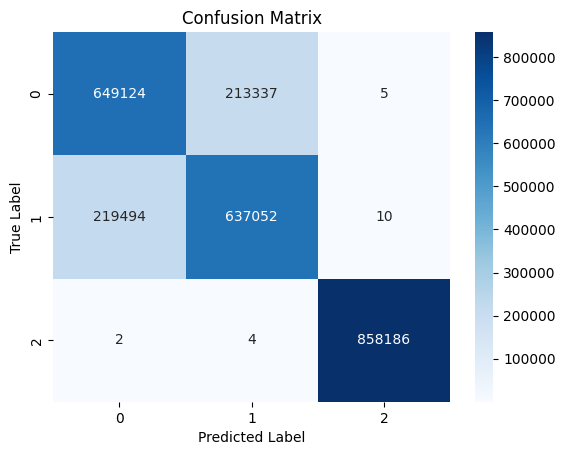

In [87]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Plot confusion matrix
conf_matrix1 = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
# Accuracy
accuracy_multi = accuracy_score(y_test_classes, y_pred_classes)

# Precision, Recall, and F1 Score with different averaging methods
precision_macro = precision_score(y_test_classes, y_pred_classes, average='macro')
recall_macro = recall_score(y_test_classes, y_pred_classes, average='macro')
f1_macro = f1_score(y_test_classes, y_pred_classes, average='macro')

precision_micro = precision_score(y_test_classes, y_pred_classes, average='micro')
recall_micro = recall_score(y_test_classes, y_pred_classes, average='micro')
f1_micro = f1_score(y_test_classes, y_pred_classes, average='micro')

precision_weighted = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall_weighted = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1_weighted = f1_score(y_test_classes, y_pred_classes, average='weighted')

print(f"Multi-Class Accuracy: {accuracy_multi}")
print(f"Macro Precision: {precision_macro}, Macro Recall: {recall_macro}, Macro F1: {f1_macro}")
print(f"Micro Precision: {precision_micro}, Micro Recall: {recall_micro}, Micro F1: {f1_micro}")
print(f"Weighted Precision: {precision_weighted}, Weighted Recall: {recall_weighted}, Weighted F1: {f1_weighted}")


Multi-Class Accuracy: 0.8320465432827852
Macro Precision: 0.8321380074414656, Macro Recall: 0.8321222529735494, Macro F1: 0.8321237273393325
Micro Precision: 0.8320465432827852, Micro Recall: 0.8320465432827852, Micro F1: 0.8320465432827852
Weighted Precision: 0.8320500171081048, Weighted Recall: 0.8320465432827852, Weighted F1: 0.8320418743396676


: 

In [46]:
model1.save('/home/pipc06/Documents/OSIRIS/Codes/Models/model_ann_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [47]:
model2.save('/home/pipc06/Documents/OSIRIS/Codes/Models/model_ann_212.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
